In [2]:
# CELL 1 — Imports
import joblib
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix, classification_report)
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# CELL 2 — Load processed data
X_train = joblib.load('../data/processed/X_train_scaled.pkl')
X_test = joblib.load('../data/processed/X_test_scaled.pkl')
y_train = joblib.load('../data/processed/y_train.pkl')
y_test = joblib.load('../data/processed/y_test.pkl')
feature_names = joblib.load('../data/processed/feature_names.pkl')

print("Data loaded. Train shape:", X_train.shape, "Test shape:", X_test.shape)

Data loaded. Train shape: (241, 13) Test shape: (61, 13)


In [4]:
# CELL 3 — Train Logistic Regression (baseline)
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8032786885245902


In [5]:
# CELL 4 — Train Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.819672131147541


In [6]:
# CELL 5 — Train XGBoost
xgb = XGBClassifier(n_estimators=200, random_state=42, eval_metric='logloss')
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

XGBoost Accuracy: 0.7049180327868853


In [7]:
# CELL 6 — Compare all models properly (accuracy, precision, recall, F1, ROC-AUC)
models = {
    'Logistic Regression': (log_reg, y_pred_lr),
    'Random Forest': (rf, y_pred_rf),
    'XGBoost': (xgb, y_pred_xgb)
}

results = []
for name, (model, y_pred) in models.items():
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.803279,0.800000,0.848485,0.823529,0.878788
1,Random Forest,0.819672,0.843750,0.818182,0.830769,0.878788
2,XGBoost,0.704918,0.727273,0.727273,0.727273,0.813853


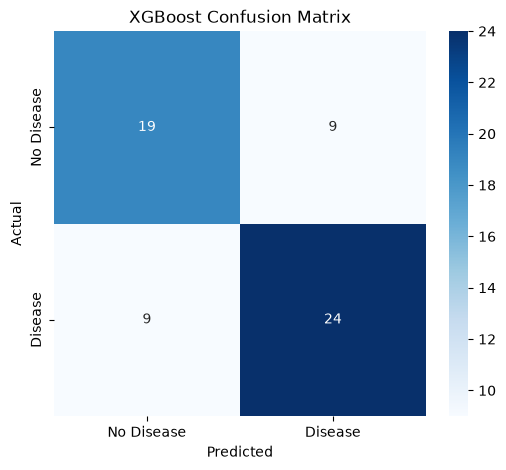

In [8]:
# CELL 7 — Confusion matrix for best model (XGBoost)
cm = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title('XGBoost Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [9]:
# CELL 8 — Save the best model (XGBoost) for the SHAP notebook and Streamlit app
joblib.dump(xgb, '../model/xgboost_model.pkl')
print("Model saved to ../model/xgboost_model.pkl")

Model saved to ../model/xgboost_model.pkl


In [10]:
# CELL 9 — Check for duplicate rows in original dataset
df_check = pd.read_csv('../data/HeartDiseaseTrain-Test.csv')
print("Total rows:", len(df_check))
print("Duplicate rows:", df_check.duplicated().sum())
print("Unique rows:", df_check.drop_duplicates().shape[0])

Total rows: 1025
Duplicate rows: 723
Unique rows: 302


Final model saved: Random Forest -> ../model/random_forest_model.pkl


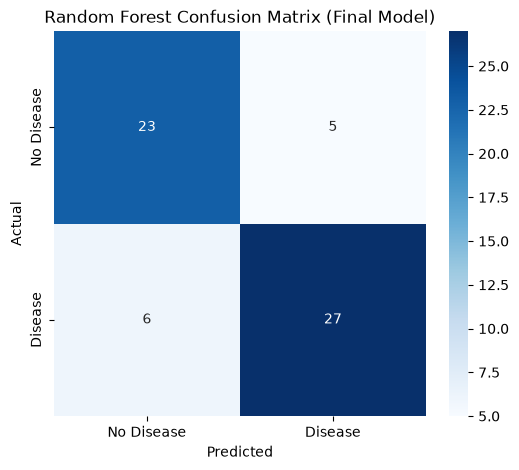

In [11]:
# CELL 10 — Save Random Forest as the FINAL model (best performer)
joblib.dump(rf, '../model/random_forest_model.pkl')
print("Final model saved: Random Forest -> ../model/random_forest_model.pkl")

# Also save its confusion matrix for the report
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title('Random Forest Confusion Matrix (Final Model)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()